# Постановка задачи

Разработать систему прогнозирования стоимости недвижимости на основе характеристик объектов недвижимости. Для этого необходимо провести анализ и предварительную обработку данных, обучить и сравнить несколько моделей регрессии и выбрать подходящую модель для прогнозирования цены



### Этап 1. Исследование данных (EDA)

##### Подключение библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('real_estate_data.csv', low_memory=False)

## Загрузка данных

Загрузим датасет и посмотрим первые и последние строки.

In [3]:

translations = {
    'type': {
        'Konut': 'Housing'
    },

    'sub_type': {
        'Daire': 'Flat',
        'Villa': 'Villa',
        'Müstakil Ev': 'Detached House',
        'Rezidans': 'Residence',
        'Yazlık': 'Summer House',
        'Komple Bina': 'Entire Building',
        'Prefabrik Ev': 'Prefabricated House',
        'Çiftlik Evi': 'Farm House',
        'Köşk / Konak / Yalı': 'Mansion / Manor / Waterfront Mansion',
        'Yalı Dairesi': 'Waterfront Apartment',
        'Kooperatif': 'Cooperative',
        'Loft': 'Loft'
    },

    'listing_type': {
        'Satılık': 'For Sale',
        'Kiralık': 'For Rent'
    },

    'furnished': {
        'Eşyalı': 'Furnished',
        'Eşyasız': 'Unfurnished',
        'Sadece Beyaz Eşya': 'White Appliances Only',
        'Sadece Mutfak': 'Kitchen Only'
    },

    'floor_no': {
        'Yüksek Giriş': 'High Ground Floor',
        'Giriş Katı': 'Ground Floor',
        'Giriş kat': 'Ground Floor',
        'Kot 1': 'Basement Level 1',
        'Kot 2': 'Basement Level 2',
        'Kot 3': 'Basement Level 3',
        'Kot 4': 'Basement Level 4',
        'Zemin Kat': 'Ground Floor',
        'Çatı Katı': 'Penthouse',
        'Bahçe katı': 'Garden Floor',
        'Müstakil': 'Detached',
        'Komple': 'Entire Building',
        '20 ve üzeri': '20 or More',
        'En Üst Kat': 'Top Floor',
        'Bodrum Kat': 'Basement Floor',
        'Teras Kat': 'Terrace Floor',
        'Asma Kat': 'Mezzanine Floor'
    },

    'heating_type': {
        'Kalorifer (Doğalgaz)': 'Central Heating / Natural Gas',
        'Kalorifer (Kömür)': 'Central Heating / Coal',
        'Kombi (Elektrikli)': 'Electric Combi Boiler',
        'Klima': 'Air Conditioning',
        'Kombi (Doğalgaz)': 'Gas Combi Boiler',
        'Merkezi Sistem': 'Central Heating',
        'Merkezi Sistem (Isı Payı Ölçer)': 'Central Heating / Heat Meter',
        'Yerden Isıtma': 'Underfloor Heating',
        'Soba (Kömür)': 'Heating Stove / Coal',
        'Soba (Doğalgaz)': 'Heating Stove / Natural Gas',
        'Güneş Enerjisi': 'Solar Energy',
        'Jeotermal': 'Geothermal Energy',
        'Fancoil': 'Fan Coil',
        'Kat Kaloriferi': 'Individual Central Heating',
        'Kalorifer (Akaryakıt)': 'Central Heating / Fuel Oil',
        'Yok': 'None'
    },

    'building_age': {
        '6-10 arası': 'Between 6 and 10 years',
        '11-15 arası': 'Between 11 and 15 years',
        '16-20 arası': 'Between 16 and 20 years',
        '21-25 arası': 'Between 21 and 25 years',
        '26-30 arası': 'Between 26 and 30 years',
        '31-35 arası': 'Between 31 and 35 years',
        '36-40 arası': 'Between 36 and 40 years',
        '40 ve üzeri': '40 years or more'
    },

    'total_floor_count': {
        '10-20 arası': 'Between 10 and 20 floors',
        '20 ve üzeri': '20 floors or more'
    },

    'price_currency': {
        'TRY': 'TRY (Turkish Lira)',
        'EUR': 'EUR (Euro)',
        'GBP': 'GBP (British Pound)',
        'USD': 'USD (US Dollar)'
    }
}

for column, mapping in translations.items():
    if column in df.columns:
        df[column] = df[column].astype(str).str.strip().replace(mapping)

In [4]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Housing,Residence,12/10/18,1/9/19,2,30,0,20 floors or more,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,nan,Fan Coil,3500.0,TRY (Turkish Lira)
1,2,Housing,Flat,2/13/19,NaN,1,14,0,20 floors or more,20 or More,1+0,43.0,İstanbul/Kartal/Kordonboyu,nan,Fan Coil,490000.0,TRY (Turkish Lira)
2,3,Housing,Flat,10/9/18,11/8/18,1,30,0,1,High Ground Floor,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,nan,Fan Coil,155000.0,TRY (Turkish Lira)
3,4,Housing,Residence,9/10/18,10/10/18,1,30,3,20 floors or more,20 or More,6+1,450.0,İstanbul/Beşiktaş/Levent,nan,Fan Coil,32500000.0,TRY (Turkish Lira)
4,5,Housing,Residence,12/10/18,1/9/19,1,30,0,20 floors or more,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,nan,Fan Coil,1450000.0,TRY (Turkish Lira)


In [5]:
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Housing,Flat,9/18/18,NaN,2,162,nan,nan,nan,+,NaN,İstanbul/Sultanbeyli/Adil,nan,nan,1500.0,TRY (Turkish Lira)
403483,403484,Housing,Flat,10/11/18,NaN,1,139,nan,nan,nan,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,nan,nan,120000.0,TRY (Turkish Lira)
403484,403485,Housing,Flat,11/22/18,NaN,1,97,nan,nan,nan,1+1,NaN,Antalya/Alanya/Saray,nan,nan,48000.0,EUR (Euro)
403485,403486,Housing,Flat,2/21/19,NaN,2,6,nan,nan,nan,2+1,2.0,Aydın/Kuşadası/Türkmen,nan,nan,900.0,TRY (Turkish Lira)
403486,403487,Housing,Flat,1/15/19,1/18/19,1,3,nan,nan,nan,3+1,140.0,Kayseri/Melikgazi/Alpaslan,nan,nan,210000.0,TRY (Turkish Lira)


In [6]:
df.shape

(403487, 17)

Посмотрим информацию о столбцах, их типах данных и наличии пропущенных значений.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  object 
 6   tom                403487 non-null  int64  
 7   building_age       403487 non-null  object 
 8   total_floor_count  403487 non-null  object 
 9   floor_no           403487 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          403487 non-null  object 
 14  heating_type       403487 non-null  object 
 15  price              402772 non-null  float64
 16  pr

### Описание признаков (Data Dictionary)

- **type (Тип_недвижимости)** — Основной тип объекта недвижимости.
  - *Konut* — Housing — Жилое

- **sub_type (Подтип_недвижимости)** — Детализированный тип жилого объекта.
  - *Daire* — Flat — Квартира
  - *Villa* — Villa — Вилла
  - *Müstakil Ev* — Detached House — Отдельно стоящий дом
  - *Rezidans* — Residence — Резиденция
  - *Yazlık* — Summer House — Летний дом
  - *Komple Bina* — Entire Building — Всё здание
  - *Prefabrik Ev* — Prefabricated House — Сборный дом
  - *Çiftlik Evi* — Farm House — Фермерский дом
  - *Köşk / Konak / Yalı* — Mansion — Особняк
  - *Yalı Dairesi* — Waterfront Apartment — Квартира на набережной
  - *Kooperatif* — Cooperative — Кооператив
  - *Loft* — Loft — Лофт

- **listing_type (Тип_объявления)** — Статус объекта на рынке.
  - *Satılık* — For Sale — Продается
  - *Kiralık* — For Rent — Сдается в аренду

- **furnished (Меблировка)** — Наличие мебели и техники в объекте.
  - *Eşyalı* — Furnished — С мебелью
  - *Eşyasız* — Unfurnished — Без мебели
  - *Sadece Beyaz Eşya* — White Appliances Only — Только крупная бытовая техника
  - *Sadece Mutfak* — Kitchen Only — Только кухонный гарнитур

- **floor_no (Номер_этажа)** — Расположение объекта относительно уровня земли.
  - *Yüksek Giriş* — High Ground Floor — Высокий первый этаж
  - *Giriş Katı* — Ground Floor — Первый этаж
  - *Kot 1* — Basement Level 1 — Цокольный этаж 1
  - *Kot 2* — Basement Level 2 — Цокольный этаж 2
  - *Kot 3* — Basement Level 3 — Цокольный этаж 3
  - *Kot 4* — Basement Level 4 — Цокольный этаж 4
  - *Zemin Kat* — Ground Floor — Первый этаж
  - *Çatı Katı* — Penthouse — Пентхаус
  - *Bahçe katı* — Garden Floor — Садовый этаж
  - *Müstakil* — Detached — Отдельно стоящий
  - *Komple* — Entire Building — Всё здание
  - *20 ve üzeri* — 20 or More — 20 и выше
  - *En Üst Kat* — Top Floor — Верхний этаж
  - *Bodrum Kat* — Basement Floor — Подвал
  - *Teras Kat* — Terrace Floor — Террасный этаж
  - *Asma Kat* — Mezzanine Floor — Антресольный этаж

- **heating_type (Тип_отопления)** — Система отопления, используемая в объекте.
  - *Kalorifer (Doğalgaz)* — Central Heating / Natural Gas — Центральное отопление на газу
  - *Kalorifer (Kömür)* — Central Heating / Coal — Центральное отопление на угле
  - *Kombi (Elektrikli)* — Electric Combi Boiler — Электрический двухконтурный котел
  - *Klima* — Air Conditioning — Кондиционер
  - *Kombi (Doğalgaz)* — Gas Combi Boiler — Газовый двухконтурный котел
  - *Merkezi Sistem* — Central Heating — Центральное отопление
  - *Merkezi Sistem (Isı Payı Ölçer)* — Central Heating / Heat Meter — Центральное отопление со счетчиком тепла
  - *Yerden Isıtma* — Underfloor Heating — Теплый пол
  - *Soba (Kömür)* — Heating Stove / Coal — Печь на угле
  - *Soba (Doğalgaz)* — Heating Stove / Natural Gas — Печь на газу
  - *Güneş Enerjisi* — Solar Energy — Солнечная энергия
  - *Jeotermal* — Geothermal Energy — Геотермальная энергия
  - *Fancoil* — Fan Coil — Фанкойл
  - *Kat Kaloriferi* — Individual Central Heating — Индивидуальное центральное отопление
  - *Kalorifer (Akaryakıt)* — Central Heating / Fuel Oil — Центральное отопление на мазуте
  - *Yok* — None — Отсутствует

- **building_age (Возраст_здания)** — Количество лет с момента постройки здания.
  - *6-10 arası* — Between 6 and 10 years — От 6 до 10 лет
  - *11-15 arası* — Between 11 and 15 years — От 11 до 15 лет
  - *16-20 arası* — Between 16 and 20 years — От 16 до 20 лет
  - *21-25 arası* — Between 21 and 25 years — От 21 до 25 лет
  - *26-30 arası* — Between 26 and 30 years — От 26 до 30 лет
  - *31-35 arası* — Between 31 and 35 years — От 31 до 35 лет
  - *36-40 arası* — Between 36 and 40 years — От 36 до 40 лет
  - *40 ve üzeri* — 40 years or more — 40 лет и более

- **total_floor_count (Общее_количество_этажей)** — Общая этажность здания.
  - *10-20 arası* — Between 10 and 20 floors — От 10 до 20 этажей
  - *20 ve üzeri* — 20 floors or more — 20 этажей и более

- **price_currency (Валюта_цены)** — Валюта, в которой указана стоимость объекта.
  - *TRY* — Turkish Lira — Турецкая лира
  - *EUR* — Euro — Евро
  - *GBP* — British Pound — Фунт стерлингов
  - *USD* — US Dollar — Доллар США

## Анализ пропущенных значений

Проверим количество пропущенных значений в каждом столбце.

Определим количество уникальных значений в каждом столбце.
Это поможет понять, какие признаки являются категориальными и насколько много в них различных категорий.


In [8]:
df.describe()

,id,tom,size,price
count,403487.00000,403487.000000,257481.000000,4.027720e+05
mean,201744.00000,57.022739,279.349094,3.546417e+05
std,116476.80837,44.358933,9429.195331,4.809503e+06
min,1.00000,0.000000,1.000000,-2.500000e+02
25%,100872.50000,29.000000,85.000000,2.500000e+03
50%,201744.00000,40.000000,110.000000,1.990000e+05
75%,302615.50000,90.000000,140.000000,3.420000e+05
max,403487.00000,180.000000,948235.000000,2.000000e+09


In [9]:
df.nunique()

id                   403487
type                      1
sub_type                 12
start_date              181
end_date                181
listing_type              3
tom                     181
building_age             15
total_floor_count        13
floor_no                 35
room_count               37
size                    943
address                7842
furnished                 1
heating_type             17
price                  3703
price_currency            5
dtype: int64

In [10]:
df.isnull().sum()

id                        0
type                      0
sub_type                  0
start_date                0
end_date             137189
listing_type              0
tom                       0
building_age              0
total_floor_count         0
floor_no                  0
room_count                0
size                 146006
address                   0
furnished                 0
heating_type              0
price                   715
price_currency            0
dtype: int64

In [11]:
missing = df.isnull().sum() / len(df) * 100
missing.sort_values(ascending=False)

size                 36.186048
end_date             34.000848
price                 0.177205
id                    0.000000
type                  0.000000
listing_type          0.000000
tom                   0.000000
sub_type              0.000000
start_date            0.000000
total_floor_count     0.000000
building_age          0.000000
room_count            0.000000
floor_no              0.000000
address               0.000000
furnished             0.000000
heating_type          0.000000
price_currency        0.000000
dtype: float64

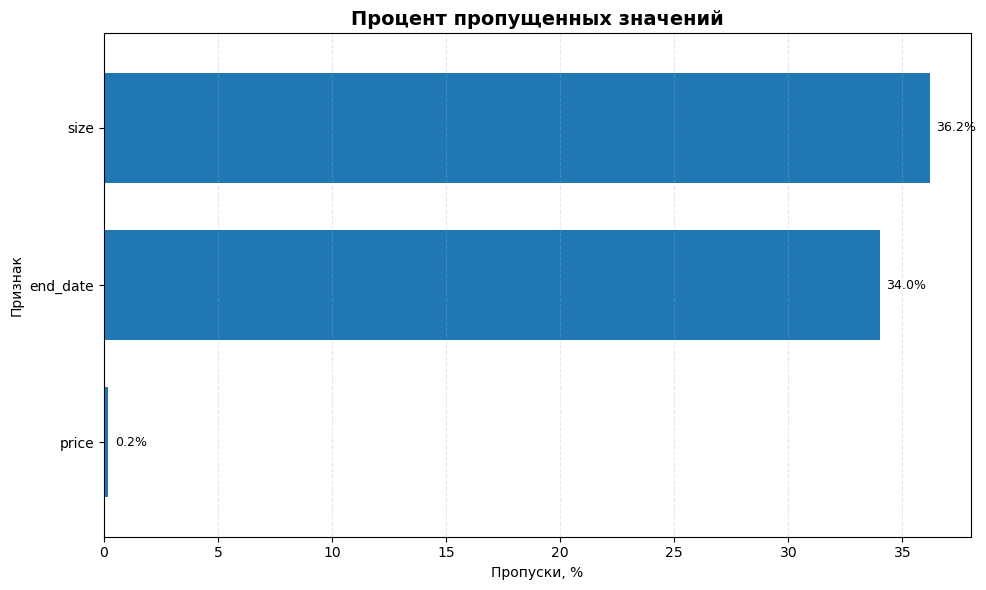

In [12]:
plt.figure(figsize=(10, 6))

missing_positive = missing[missing > 0].sort_values()

ax = missing_positive.plot(kind='barh', width=0.7)

plt.title('Процент пропущенных значений',
          fontsize=14, fontweight='bold')
plt.xlabel('Пропуски, %')
plt.ylabel('Признак')

plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, value in enumerate(missing_positive):
    ax.text(value + 0.3, i, f'{value:.1f}%',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
df.duplicated().sum()

np.int64(0)

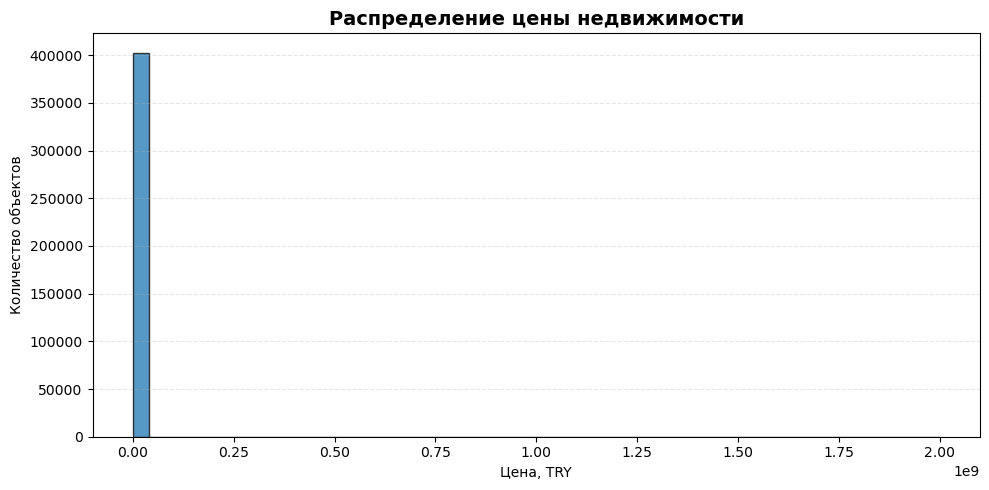

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['price'].dropna(),
    bins=50,
    edgecolor='black',
    alpha=0.75
)

plt.title('Распределение цены недвижимости',
          fontsize=14, fontweight='bold')
plt.xlabel('Цена, TRY')
plt.ylabel('Количество объектов')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
print('Минимальная цена:', df['price'].min())
print('Максимальная цена:', df['price'].max())
print('Средняя цена:', df['price'].mean())
print('Медианная цена:', df['price'].median())
print('Стандартное отклонение:', df['price'].std())

Минимальная цена: -250.0
Максимальная цена: 2000000000.0
Средняя цена: 354641.66193280567
Медианная цена: 199000.0
Стандартное отклонение: 4809502.70410212


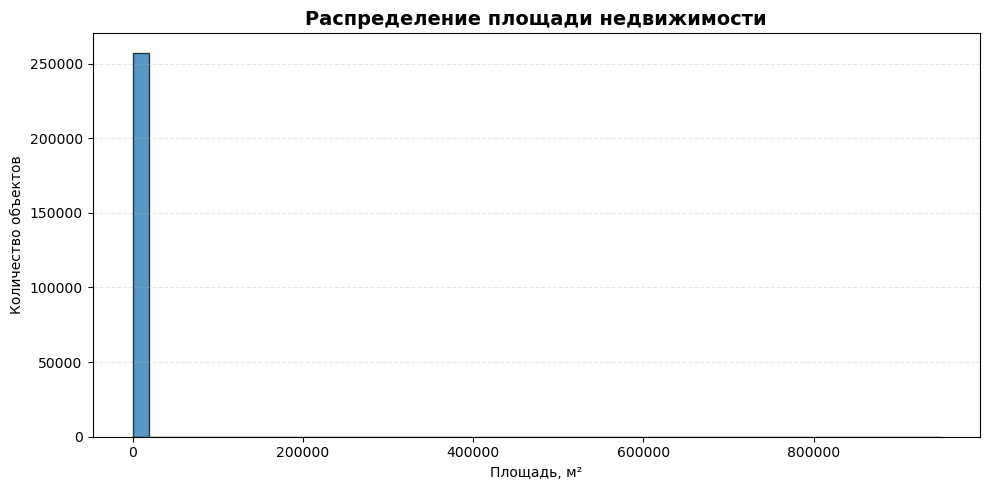

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['size'].dropna(),
    bins=50,
    edgecolor='black',
    alpha=0.75
)

plt.title('Распределение площади недвижимости',
          fontsize=14, fontweight='bold')
plt.xlabel('Площадь, м²')
plt.ylabel('Количество объектов')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

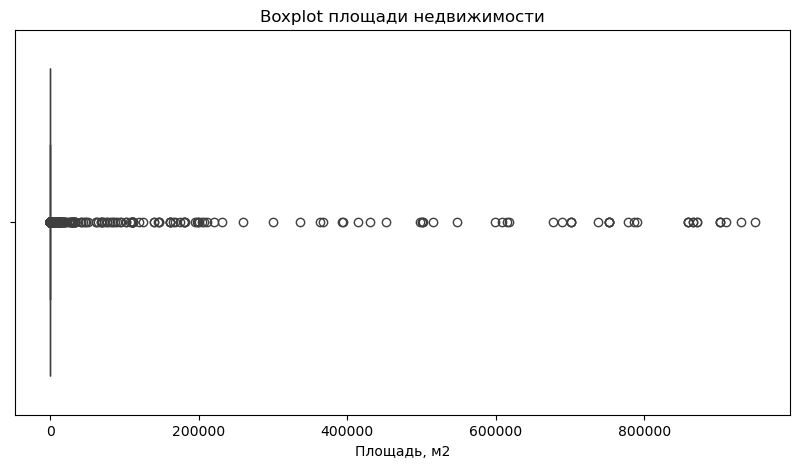

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['size'])

plt.title('Boxplot площади недвижимости')
plt.xlabel('Площадь, м2')

plt.show()

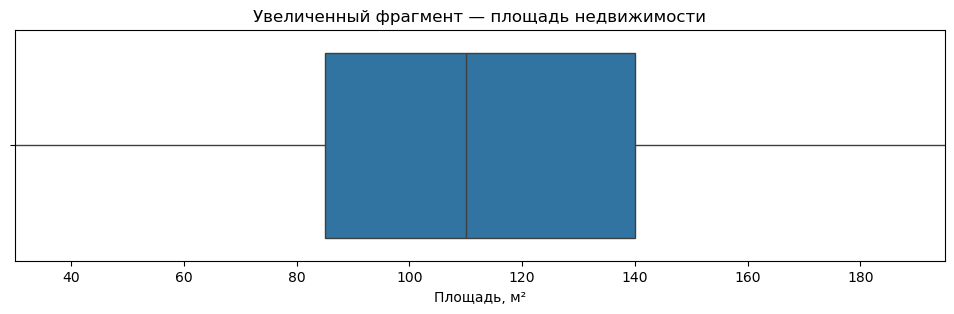

In [18]:
plt.figure(figsize=(12, 3))

sns.boxplot(x=df['size'])

plt.title('Увеличенный фрагмент — площадь недвижимости')
plt.xlabel('Площадь, м²')

q1 = df['size'].quantile(0.25)
q3 = df['size'].quantile(0.75)

plt.xlim(
    q1 - (q3 - q1),
    q3 + (q3 - q1)
)

plt.show()

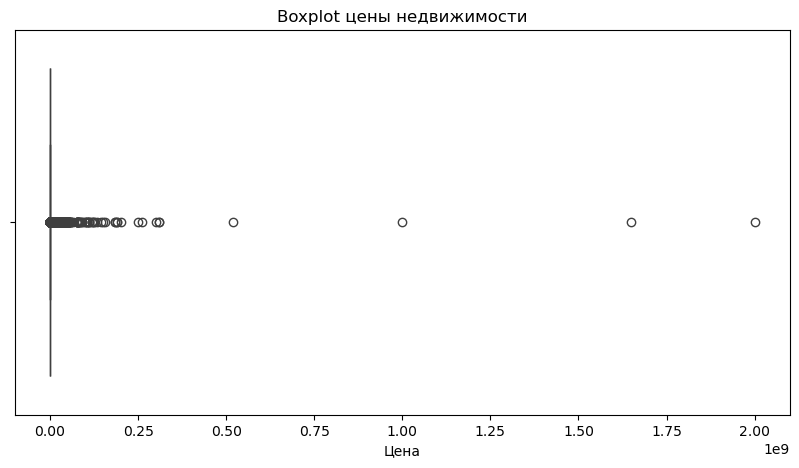

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['price'])

plt.title('Boxplot цены недвижимости')
plt.xlabel('Цена')

plt.show()

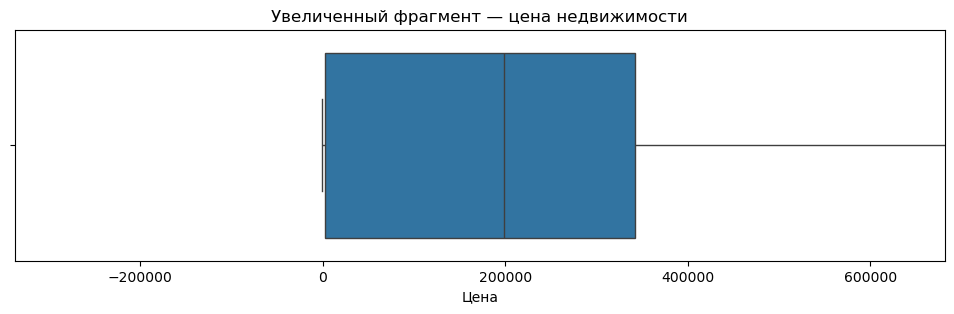

In [20]:
plt.figure(figsize=(12, 3))

sns.boxplot(x=df['price'])

plt.title('Увеличенный фрагмент — цена недвижимости')
plt.xlabel('Цена')

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

plt.xlim(
    q1 - (q3 - q1),
    q3 + (q3 - q1)
)

plt.show()

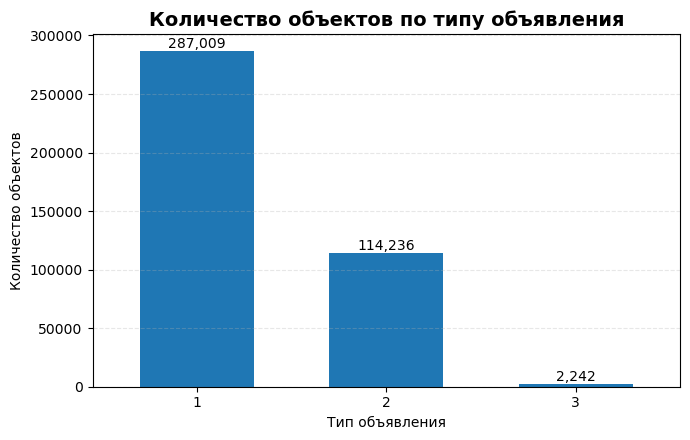

In [21]:
plt.figure(figsize=(7, 4.5))

listing_counts = df['listing_type'].value_counts()

ax = listing_counts.plot(kind='bar', width=0.6)

plt.title('Количество объектов по типу объявления',
          fontsize=14, fontweight='bold')
plt.xlabel('Тип объявления')
plt.ylabel('Количество объектов')

plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, value in enumerate(listing_counts):
    ax.text(i, value, f'{value:,}',
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

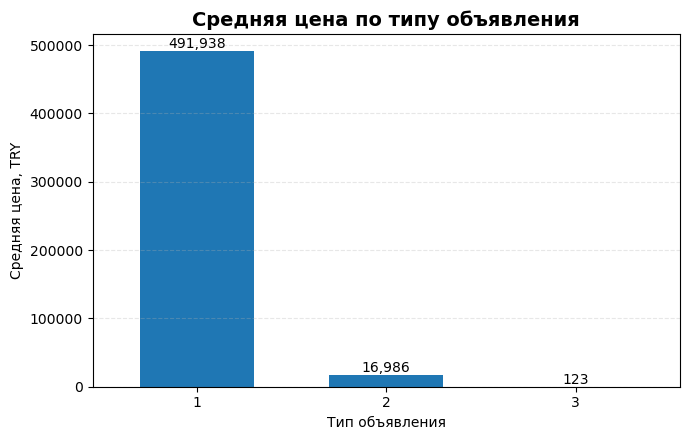

In [22]:
plt.figure(figsize=(7, 4.5))

mean_price = df.groupby('listing_type')['price'].mean()

ax = mean_price.plot(kind='bar', width=0.6)

plt.title('Средняя цена по типу объявления',
          fontsize=14, fontweight='bold')
plt.xlabel('Тип объявления')
plt.ylabel('Средняя цена, TRY')

plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, value in enumerate(mean_price):
    ax.text(i, value, f'{value:,.0f}',
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
df['room_count'].value_counts().head(15)

room_count
3+1    157363
2+1    138677
1+1     39134
4+1     37472
5+1      8219
4+2      4540
5+2      2926
+        2898
3+2      2673
1+0      2612
6+1      2001
6+2      1517
2+2       836
7+1       523
7+2       428
Name: count, dtype: int64

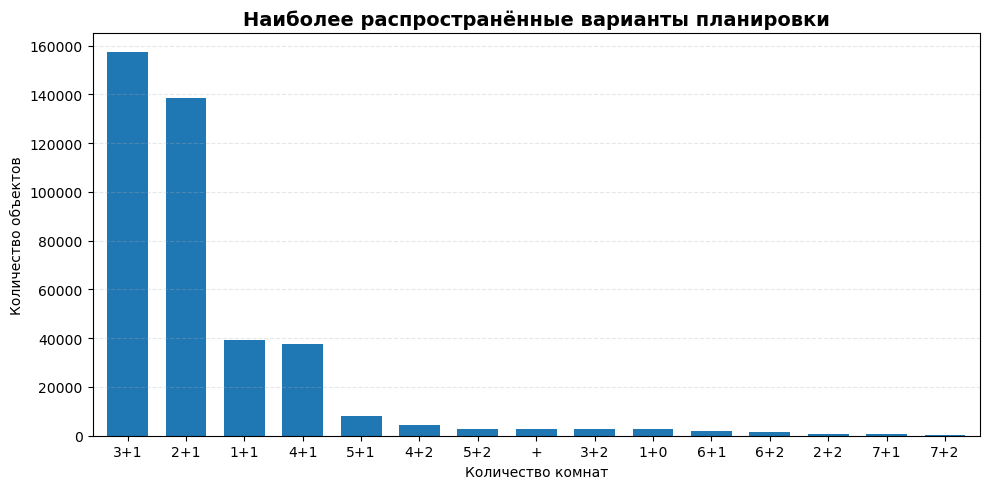

In [24]:
plt.figure(figsize=(10, 5))

room_counts = df['room_count'].value_counts().head(15)

ax = room_counts.plot(kind='bar', width=0.7)

plt.title('Наиболее распространённые варианты планировки',
          fontsize=14, fontweight='bold')
plt.xlabel('Количество комнат')
plt.ylabel('Количество объектов')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

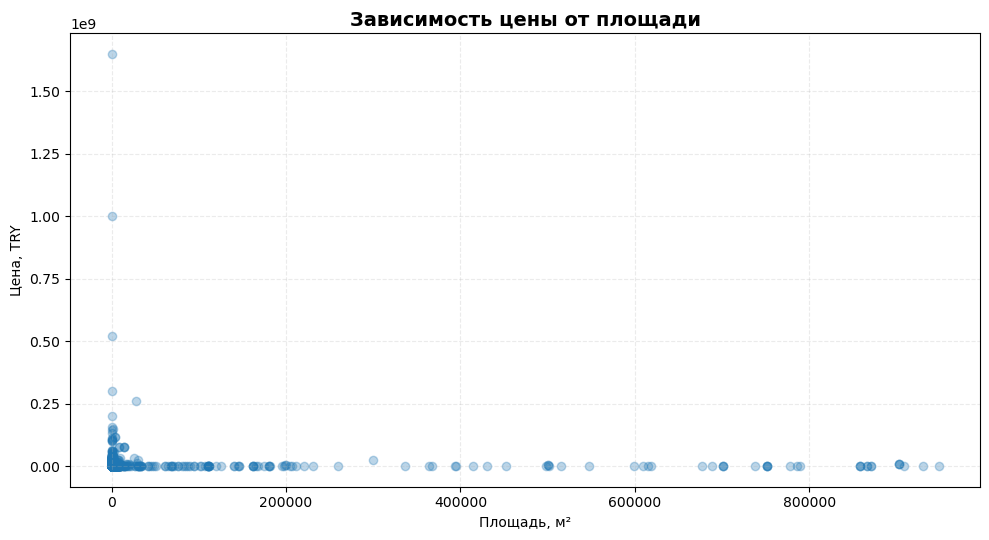

In [25]:
plt.figure(figsize=(10, 5.5))

plt.scatter(
    df['size'],
    df['price'],
    alpha=0.3
)

plt.title('Зависимость цены от площади',
          fontsize=14, fontweight='bold')
plt.xlabel('Площадь, м²')
plt.ylabel('Цена, TRY')

plt.grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

## Анализ корреляции

Рассчитаем корреляцию между числовыми признаками

In [26]:
numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()

correlation

,id,tom,size,price
id,1.000000,-0.003890,0.008551,-0.001938
tom,-0.003890,1.000000,-0.011847,0.011818
size,0.008551,-0.011847,1.000000,0.005889
price,-0.001938,0.011818,0.005889,1.000000


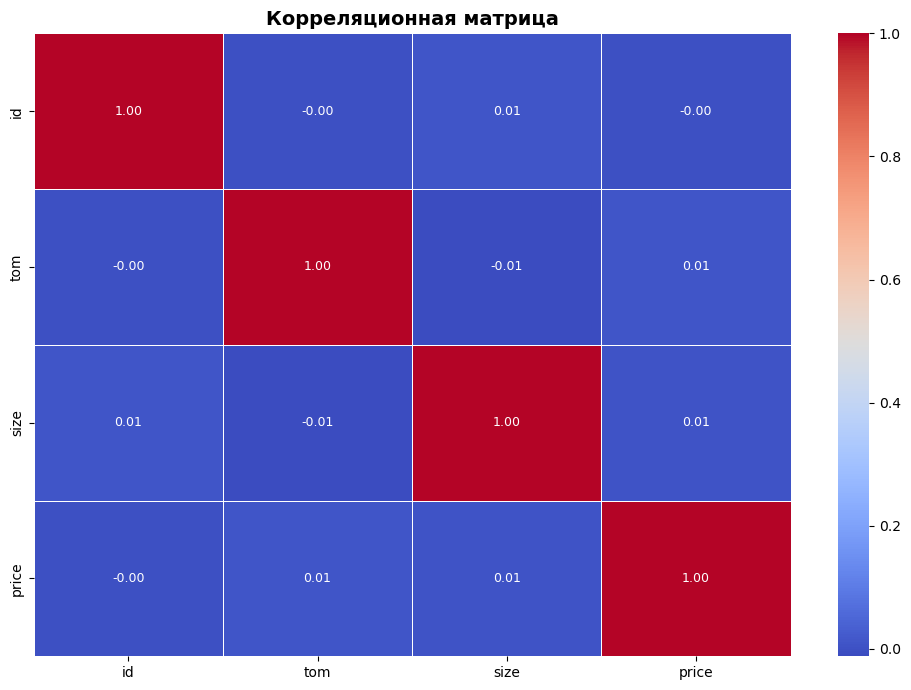

In [27]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Корреляционная матрица',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
print('Цена <= 0:', (df['price'] <= 0).sum())
print('Площадь <= 0:', (df['size'] <= 0).sum())

Цена <= 0: 45
Площадь <= 0: 0


In [29]:
print('Минимальная площадь:', df['size'].min())
print('Максимальная площадь:', df['size'].max())

print('Минимальная цена:', df['price'].min())
print('Максимальная цена:', df['price'].max())

Минимальная площадь: 1.0
Максимальная площадь: 948235.0
Минимальная цена: -250.0
Максимальная цена: 2000000000.0


In [30]:
print('Минимальная площадь:', df['size'].min())
print('Максимальная площадь:', df['size'].max())

print('Минимальная цена:', df['price'].min())
print('Максимальная цена:', df['price'].max())

Минимальная площадь: 1.0
Максимальная площадь: 948235.0
Минимальная цена: -250.0
Максимальная цена: 2000000000.0


### Вывод 1 этапа

В ходе первого этапа был проведён анализ данных о недвижимости: изучены структура, статистика, пропуски, дубликаты и распределение цены. С помощью графиков исследованы зависимости цены от площади, количества комнат и других характеристик.

По результатам EDA можно предположить, что на цену влияют площадь, количество комнат, расположение, этаж и другие признаки. Далее необходимо выполнить обработку данных и подготовить их к построению моделей.


## Этап 2. Предварительная обработка данных

### 2.1 Работа с пропусками

In [31]:
df = df.replace(['nan', 'NaN','null', 'None', ' ','-'], np.nan)

C:\Users\poula\AppData\Local\Temp\ipykernel_23988\583877007.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['nan', 'NaN','null', 'None', ' ','-'], np.nan)


In [32]:
df.isna().sum()

id                        0
type                      0
sub_type                  0
start_date                0
end_date             137189
listing_type              0
tom                       0
building_age          27390
total_floor_count     28021
floor_no              35296
room_count                0
size                 146006
address                   0
furnished            403487
heating_type          34068
price                   715
price_currency          715
dtype: int64

In [33]:
df = df.drop(columns=['furnished'])

Столбец furnished(Наличие мебели и техники в объекте) на 100% пуст,именно поэтому он бесполезен.

In [34]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

C:\Users\poula\AppData\Local\Temp\ipykernel_23988\2269234919.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
C:\Users\poula\AppData\Local\Temp\ipykernel_23988\2269234919.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')


Преобразуем даты в datatime

In [35]:
df['is_active'] = df['end_date'].isna().astype(int)

Создаем флаг активности

In [36]:
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days.fillna(0)
df['end_month'] = df['end_date'].dt.month.fillna(-1).astype(int)

Вычисляем длительность объявления и месяц его окончания

In [37]:
df.drop(columns=['start_date', 'end_date'], inplace=True)

Удаляем колонки start_date и end_date

In [38]:
df['building_age'].value_counts(dropna=False)

building_age
0                          140174
Between 6 and 10 years      50495
Between 11 and 15 years     32309
Between 16 and 20 years     31333
NaN                         27390
1                           20355
4                           19032
Between 21 and 25 years     18438
2                           17466
3                           15651
5                           13589
Between 26 and 30 years     10581
Between 31 and 35 years      4268
Between 36 and 40 years      1347
40 years or more             1059
Name: count, dtype: int64

Проверяем все уникальные значения возраста недвижимости

In [39]:
mapping = {
    'Between 6 and 10 years': 8,
    'Between 11 and 15 years': 13,
    'Between 16 and 20 years': 18,
    'Between 21 and 25 years': 23,
    'Between 26 and 30 years': 28,
    'Between 31 and 35 years': 33,
    'Between 36 and 40 years': 38,
    '40 years or more': 45,
}

df['building_age'] = df['building_age'].replace(mapping)
df['building_age'] = pd.to_numeric(df['building_age'], errors='coerce')

Преобразовали текстовые категории в числа.

In [40]:
df['building_age'] = df['building_age'].fillna(df['building_age'].median())

Заполняем пропуски медианой

In [41]:
df['total_floor_count'].value_counts(dropna=False)

total_floor_count
4                           83082
3                           77956
5                           70104
Between 10 and 20 floors    36512
NaN                         28021
2                           27742
6                           23348
10                          12558
7                           12284
8                           11207
9                            9029
20 floors or more            6679
1                            4965
Name: count, dtype: int64

In [42]:
mapping = {
    'Between 10 and 20 floors': 15,
    '20 floors or more': 25,
}

df['total_floor_count'] = df['total_floor_count'].replace(mapping)
df['total_floor_count'] = pd.to_numeric(df['total_floor_count'], errors='coerce')

Преобразовали текстовые категории в числа.

In [43]:
df['total_floor_count'] = df.groupby('sub_type')['total_floor_count'].transform(
    lambda s: s.fillna(s.median()))
df['total_floor_count'] = df['total_floor_count'].fillna(df['total_floor_count'].median())

Заполняем медианой по типу жилья.

In [44]:
df['floor_no'].value_counts(dropna=False)

floor_no
2                    65864
3                    52690
1                    46756
NaN                  35296
4                    34465
High Ground Floor    24045
5                    21193
Detached             21165
Garden Floor         19065
Ground Floor         13872
6                     9747
7                     7698
8                     6099
Basement Level 1      5036
Basement Level 2      4987
9                     4855
10                    3863
Basement Level 3      3793
Penthouse             3566
Entire Building       2958
11                    2894
12                    2309
Basement Level 4      2269
13                    1702
20 or More            1563
14                    1328
15                     911
Top Floor              894
Basement Floor         815
16                     600
17                     373
18                     334
Terrace Floor          293
19                     177
Mezzanine Floor         12
Name: count, dtype: int64

In [45]:
mapping = {
    'Ground Floor': 0,
    'High Ground Floor': 0,
    'Garden Floor': -1,
    'Basement Floor': -1,
    'Basement Level 1': -1,
    'Basement Level 2': -2,
    'Basement Level 3': -3,
    'Basement Level 4': -4,
    'Mezzanine Floor': 0.5,
    'Detached': 0,
    'Entire Building': 0,
    'Penthouse': None,
    'Top Floor': None,
    'Terrace Floor': None,
    '20 or More': 20,
}

df['floor_no'] = df['floor_no'].replace(mapping)
df['floor_no'] = pd.to_numeric(df['floor_no'], errors='coerce')

Преобразовали текстовые категории в числа.

In [46]:
df['floor_no'] = df.groupby('sub_type')['floor_no'].transform(
    lambda s: s.fillna(s.median())
)
df['floor_no'] = df['floor_no'].fillna(df['floor_no'].median())

Заполняем пропуски этажа медианой по типу жилья

In [47]:
df['size'].value_counts(dropna=False).head(20)

size
NaN      146006
90.0      16803
100.0     16234
120.0     15543
110.0     13546
80.0      11094
130.0     10918
85.0      10437
140.0      9103
150.0      8580
95.0       8036
125.0      7623
75.0       6966
135.0      6514
70.0       6264
115.0      6244
160.0      5923
105.0      4873
60.0       4528
180.0      4334
Name: count, dtype: int64

In [48]:
df['size'] = df.groupby(['sub_type', 'room_count'])['size'].transform(
    lambda s: s.fillna(s.median())
)
df['size'] = df['size'].fillna(df['size'].median())

Заполняем пропуски площади медианой по типу жилья и числу комнат.

In [49]:
df['heating_type'].value_counts(dropna=False)

heating_type
Gas Combi Boiler                 204150
Air Conditioning                  68197
NaN                               34068
Central Heating / Heat Meter      30595
Central Heating                   22855
Central Heating / Natural Gas     10928
Heating Stove / Coal               8450
Underfloor Heating                 6958
Individual Central Heating         5655
Electric Combi Boiler              3449
Heating Stove / Natural Gas        2602
Solar Energy                       1754
Central Heating / Coal             1503
Geothermal Energy                  1418
Fan Coil                            495
Central Heating / Fuel Oil          410
Name: count, dtype: int64

In [50]:
df['heating_type'] = df['heating_type'].fillna(df['heating_type'].mode()[0])

Заполняем тип отопления модой.

In [51]:
df = df.dropna(subset=['price', 'price_currency'])

Удаляем строки с ценами.

In [52]:
df.isna().sum()

id                   0
type                 0
sub_type             0
listing_type         0
tom                  0
building_age         0
total_floor_count    0
floor_no             0
room_count           0
size                 0
address              0
heating_type         0
price                0
price_currency       0
is_active            0
duration_days        0
end_month            0
dtype: int64

Все пропуски заполнены.

### 2.2 Обработка новой

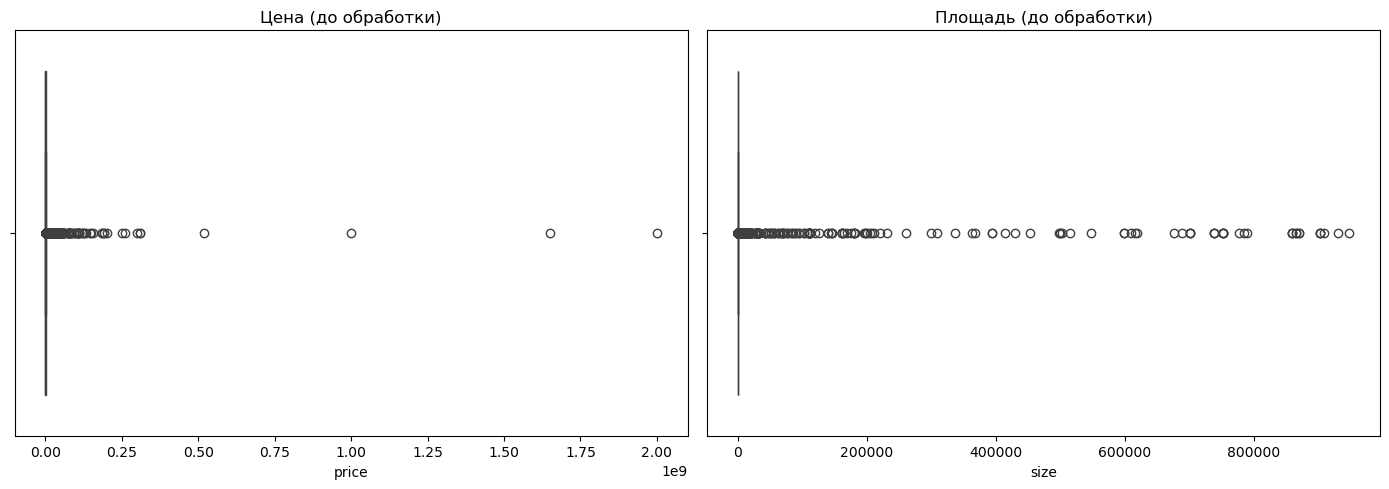

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['price'], ax=axes[0])
axes[0].set_title('Цена (до обработки)')

sns.boxplot(x=df['size'], ax=axes[1])
axes[1].set_title('Площадь (до обработки)')

plt.tight_layout()
plt.show()

В данных о цене и площади присутствуют выбросы, искажающие шкалу и статистику

#### Удаление явных ошибок

In [54]:
print("Цена <= 0:", (df['price'] <= 0).sum())
print("Площадь <= 0:", (df['size'] <= 0).sum())
print("Площадь > 10000 м²:", (df['size'] > 10000).sum())
print("Цена > 1e9:", (df['price'] > 1e9).sum())

Цена <= 0: 45
Площадь <= 0: 0
Площадь > 10000 м²: 168
Цена > 1e9: 2


Смотрим строки с плохими значениями.

In [55]:
df = df[df['price'] > 0]
df = df[df['size'] <= 10000]
df = df[df['price'] <= 1e9]

Удалили проблемные строки

#### Винсоризация

In [56]:
rates = {'TRY (Turkish Lira)': 49.01, 'USD (US Dollar)': 1, 'EUR (Euro)': 0.88, 'GBP (British Pound)': 0.75}
df['price_usd'] = df['price'] / df['price_currency'].map(rates)

Перевели все в доллары.

In [57]:
print(df[['price', 'price_currency', 'price_usd']].head(10))

        price       price_currency      price_usd
0      3500.0   TRY (Turkish Lira)      71.413997
1    490000.0   TRY (Turkish Lira)    9997.959600
2    155000.0   TRY (Turkish Lira)    3162.619873
3  32500000.0   TRY (Turkish Lira)  663129.973475
4   1450000.0   TRY (Turkish Lira)   29585.798817
5    780000.0   TRY (Turkish Lira)   15915.119363
6      3750.0   TRY (Turkish Lira)      76.514997
7   1500000.0   TRY (Turkish Lira)   30605.998776
8   1500000.0   TRY (Turkish Lira)   30605.998776
9     84256.0  GBP (British Pound)  112341.333333


In [58]:
df = df.drop(columns=['price', 'price_currency'])

Удаляем старые столбцы

In [59]:
def winsorize(series, low=0.01, high=0.99):
    lower = series.quantile(low)
    upper = series.quantile(high)
    return series.clip(lower, upper)

print("Цена, 1% и 99% перцентили:")
print(df['price_usd'].quantile([0.01, 0.99]))

print("\nПлощадь, 1% и 99% перцентили:")
print(df['size'].quantile([0.01, 0.99]))

Цена, 1% и 99% перцентили:
0.01       10.202000
0.99    76514.996939
Name: price_usd, dtype: float64

Площадь, 1% и 99% перцентили:
0.01     40.0
0.99    380.0
Name: size, dtype: float64


Цены и площади имеют выраженные выбросы: 1% объектов дешевле 10 USD и меньше 40 м², а 99% — дороже 58 151 USD и больше 380 м².

In [60]:
df['price_usd'] = winsorize(df['price_usd'])
df['size'] = winsorize(df['size'])

print("Цена после винсоризации:")
print(df['price_usd'].describe())
print("\nПлощадь после винсоризации:")
print(df['size'].describe())

Цена после винсоризации:
count    402557.000000
mean       6261.274322
std       10391.046667
min          10.202000
25%          51.009998
50%        4080.799837
75%        7080.187717
max       76514.996939
Name: price_usd, dtype: float64

Площадь после винсоризации:
count    402557.000000
mean        121.480584
std          54.800105
min          40.000000
25%          90.000000
50%         115.000000
75%         135.000000
max         380.000000
Name: size, dtype: float64


Максимальная цена снизилась до 58 151 USD, а площадь — до 380 м², при этом медианная цена составляет 4 081 USD, а типичная площадь — 115 м².

#### Логарифмирование скошенных признаков

In [61]:
print("Асимметрия цены до:", df['price_usd'].skew())
print("Асимметрия площади до:", df['size'].skew())

Асимметрия цены до: 4.531363935459397
Асимметрия площади до: 1.962416459027027


Данные сильно скошены вправо, что требует логарифмирования выбросов перед использованием моделей

In [62]:
df['price_log'] = np.log1p(df['price_usd'])
df['size_log'] = np.log1p(df['size'])

print("Асимметрия цены после:", df['price_log'].skew())
print("Асимметрия площади после:", df['size_log'].skew())

Асимметрия цены после: -0.7849966549680691
Асимметрия площади после: 0.2057692451480447


Логарифмирование хорошо нормализовало обе переменные, особенно площадь.

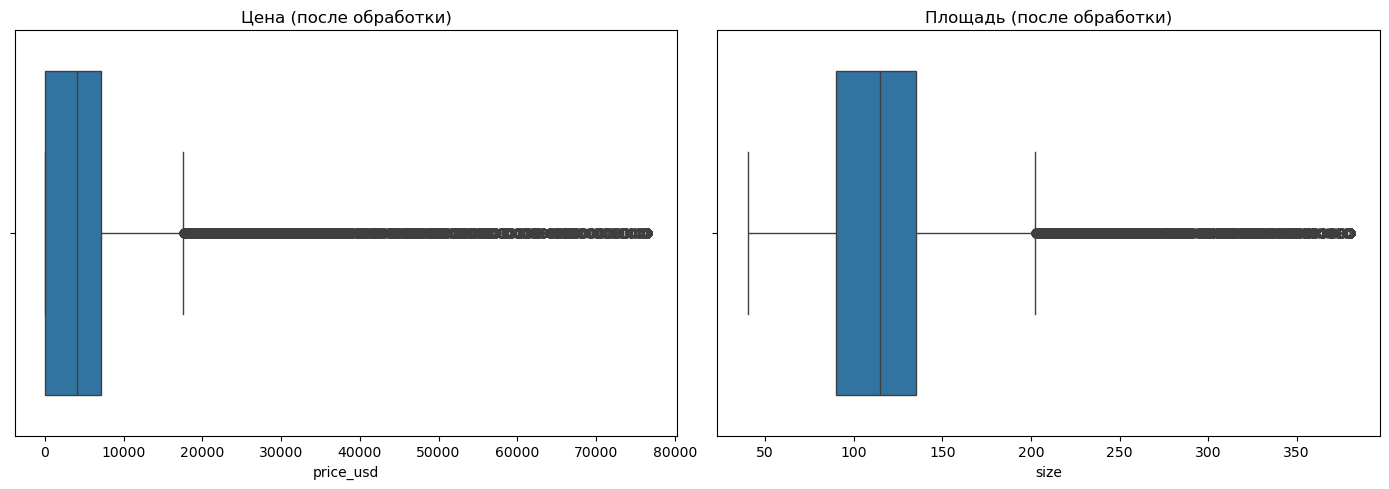

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['price_usd'], ax=axes[0])
axes[0].set_title('Цена (после обработки)')

sns.boxplot(x=df['size'], ax=axes[1])
axes[1].set_title('Площадь (после обработки)')

plt.tight_layout()
plt.show()

Несмотря на что видны длинные хвосты выбросов, логарифмирование успешно сжало масштаб данных и приблизило распределение к нормальному.

### 2.3 Кодирование категориальных признаков

In [64]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print(f"{c:20s} | уникальных: {df[c].nunique():6d}")

type                 | уникальных:      1
sub_type             | уникальных:     12
listing_type         | уникальных:      3
room_count           | уникальных:     37
address              | уникальных:   7813
heating_type         | уникальных:     15


In [65]:
df = df.drop(columns=['type'])

Удаляем столбец type потому что в нем лишь 1 уникальное значение.

In [66]:
nominal = ['sub_type', 'listing_type', 'heating_type']
df = pd.get_dummies(df, columns=nominal, drop_first=True, dtype=int)

Преобразуем текстовые столбцы в наборы столбцов из 0 и 1, чтобы модель могла с ними работать.

In [67]:
def parse_rooms(x):
    if pd.isna(x):
        return np.nan
    parts = str(x).replace(' ', '').split('+')
    try:
        return sum(int(p) for p in parts if p.isdigit())
    except ValueError:
        return np.nan

df['room_count_num'] = df['room_count'].apply(parse_rooms)
df = df.drop(columns=['room_count'])

In [68]:
df['room_count_num'].value_counts().sort_index()

room_count_num
0       2296
1       2605
2      39093
3     138605
4     158115
5      40130
6      12744
7       5046
8       2164
9        802
10       643
11       136
12       118
13        34
14        23
15         2
20         1
Name: count, dtype: int64

Превращает текстовый столбец с комнатами в числовой и удаляет старый.

In [69]:
parts = df['address'].str.split('/')
df['city']     = parts.str[0].str.strip()
df['district'] = parts.str[1].str.strip()

Делим адресс на столбцы город и район

In [70]:
df = pd.get_dummies(df, columns=['city'], drop_first=True, dtype=int)

Столбец city преобразовываем в набор столбцов из 0 и 1

In [71]:
district_mean = df.groupby('district')['price_log'].mean()
df['district_enc'] = df['district'].map(district_mean)

df = df.drop(columns=['district', 'address'])

Район заменяется средним значением цены по этому району, а лишние столбцы удаляются.

### 2.4 Feature Engineering

#### 1. Создание новых признаков

In [72]:
df['price_per_sqm'] = df['price_usd'] / df['size']

Создали новый признак - цена за квадратный метр

#### 2. Проверка на мультиколлинеарность

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_features = ['building_age', 'total_floor_count', 'floor_no', 'size_log', 
    'is_active', 'duration_days', 'end_month', 'room_count_num'
]

vif_features = [col for col in vif_features if col in df.columns]

X_vif = df[vif_features].copy()

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(by='VIF', ascending=False)

print("VIF анализ для числовых признаков:")
print(vif_data)

VIF анализ для числовых признаков:
             feature       VIF
5          is_active  3.226332
4           size_log  2.770475
8     room_count_num  2.765796
7          end_month  2.086931
6      duration_days  1.845010
2  total_floor_count  1.712608
3           floor_no  1.700964
1       building_age  1.017141


Проверка VIF показала отсутствие мультиколлинеарности — данные готовы к обучению

### 2.5 Масштабирование признаков

In [74]:
from sklearn.preprocessing import RobustScaler

numeric_features = ['building_age', 'total_floor_count', 'floor_no',
                    'duration_days', 'end_month', 'room_count_num']

scaler = RobustScaler()

In [75]:
print(df[numeric_features].describe())

        building_age  total_floor_count       floor_no  duration_days  \
count  402557.000000      402557.000000  402557.000000  402557.000000   
mean        6.637222           5.822554       2.485352      32.289621   
std         8.478095           4.312409       3.157931      37.380889   
min         0.000000           1.000000      -4.000000       0.000000   
25%         0.000000           3.000000       0.000000       0.000000   
50%         3.000000           5.000000       2.000000      30.000000   
75%         8.000000           6.000000       4.000000      60.000000   
max        45.000000          25.000000      20.000000     180.000000   

           end_month  room_count_num  
count  402557.000000   402557.000000  
mean        4.015091        3.667029  
std         5.320413        1.163162  
min        -1.000000        0.000000  
25%        -1.000000        3.000000  
50%         2.000000        4.000000  
75%        11.000000        4.000000  
max        12.000000       20.

Признаки успешно масштабированы . Данные готовы к обучению линейных моделей.

### 2.6 Разбиение данных

In [76]:
from sklearn.model_selection import train_test_split

target = 'price_log'

features_to_exclude = ['price_usd', 'price_per_sqm', 'price_log', 'id']

feature_cols = [col for col in df.columns if col not in features_to_exclude]

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train размер: {X_train.shape}")
print(f"Test размер: {X_test.shape}")

Train размер: (322045, 119)
Test размер: (80512, 119)


Данные успешно разделены на обучающую и тестовую выборки без утечек

## Вывод этап 2

На втором этапе данные были подготовлены для обучения моделей: обработаны пропуски и выбросы, преобразованы категориальные признаки и созданы дополнительные признаки. Также данные были разделены на обучающую и тестовую выборки и выполнено масштабирование числовых признаков.

# Этап 3. Построение модели регрессии


На данном этапе построим несколько моделей машинного обучения для прогнозирования стоимости недвижимости.

Будут использованы три модели разного типа: линейная регрессия, дерево решений и случайный лес. После обучения модели будут сравнены по нескольким метрикам качества.

## Подготовка данных для обучения

Перед обучением моделей исключим признаки, которые могут привести к утечке целевой переменной.

В качестве целевой переменной используется price_try

In [77]:
feature_cols = [
    'building_age',
    'total_floor_count',
    'floor_no',
    'size_log',
    'is_active',
    'duration_days',
    'end_month',
    'room_count_num',
    'district_enc'
]

ohe_features = [col for col in df.columns if col.startswith(('sub_type_', 'listing_type_', 'heating_type_', 'city_'))]
feature_cols += ohe_features

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols]
y = df['price_log']

print('Количество признаков:', X.shape[1])
print('Количество объектов:', X.shape[0])

Количество признаков: 117
Количество объектов: 402557


Разделим данные на обучающую и тестовую выборки

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Размер X_train:', X_train.shape)
print('Размер X_test:', X_test.shape)
print('Размер y_train:', y_train.shape)
print('Размер y_test:', y_test.shape)

Размер X_train: (322045, 117)
Размер X_test: (80512, 117)
Размер y_train: (322045,)
Размер y_test: (80512,)


## 3.1 Линейная модель — Ridge Regression


### Метрики качества

Для оценки моделей будем использовать четыре метрики:

- MAE - средняя абсолютная ошибка;
- RMSE - среднеквадратичная ошибка;
- MAPE - средняя процентная ошибка;
- R² - доля объяснённой моделью вариации целевой переменной.

In [79]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Создаём модель

In [80]:
df_model = pd.concat([X, y], axis=1).dropna()
X_clean = df_model[feature_cols]
y_clean = df_model['price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

Удаляем пустые строки

In [81]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

### Оценка базовой модели
Рассчитаем основные метрики качества для базовой модели Ridge Regression.

In [82]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_mape = mean_absolute_percentage_error(
    y_test,
    ridge_pred
) * 100

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print('Ridge Regression')
print('MAE:', ridge_mae)
print('RMSE:', ridge_rmse)
print('MAPE:', ridge_mape, '%')
print('R²:', ridge_r2)

Ridge Regression
MAE: 0.3673479192785557
RMSE: 0.5522991904246599
MAPE: 6.185321097227975 %
R²: 0.9529570807293978


##### Подбор гиперпараметров
Для улучшения модели выполним подбор параметра alpha
Подбор выполняется с помощью GridSearchCV и кросс-валидации на обучающей выборке.

In [83]:
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print('Лучшие параметры:')
print(ridge_grid.best_params_)

Лучшие параметры:
{'alpha': 0.1}


#### Итоговая модель Ridge Regression
Используем найденное значение параметра и повторно оценим качество модели на тестовой выборке.

In [84]:
ridge_best = ridge_grid.best_estimator_

ridge_best_pred = ridge_best.predict(X_test)

ridge_best_mae = mean_absolute_error(
    y_test,
    ridge_best_pred
)

ridge_best_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_best_pred)
)

ridge_best_mape = mean_absolute_percentage_error(
    y_test,
    ridge_best_pred
) * 100

ridge_best_r2 = r2_score(
    y_test,
    ridge_best_pred
)

print('Ridge Regression — после подбора')
print('MAE:', ridge_best_mae)
print('RMSE:', ridge_best_rmse)
print('MAPE:', ridge_best_mape)
print('R²:', ridge_best_r2)

Ridge Regression — после подбора
MAE: 0.3673546127176109
RMSE: 0.552287048714235
MAPE: 6.1853371142228
R²: 0.9529591490837782


# 3.2 Дерево решений

Следующей рассмотрим модель Decision Tree Regressor.

Дерево решений позволяет находить нелинейные зависимости между характеристиками недвижимости и её стоимостью

In [85]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

Оценка базовой модели


In [86]:
tree_mae = mean_absolute_error(
    y_test,
    tree_pred
)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_mape = mean_absolute_percentage_error(
    y_test,
    tree_pred
) * 100

tree_r2 = r2_score(
    y_test,
    tree_pred
)

print('Decision Tree')
print('MAE:', tree_mae)
print('RMSE:', tree_rmse)
print('MAPE:', tree_mape)
print('R²:', tree_r2)

Decision Tree
MAE: 0.2647346531750757
RMSE: 0.5351086042354486
MAPE: 4.514476655615033
R²: 0.9558399740961977


#### Подбор гиперпараметров

Подберём параметры глубины дерева и минимального количества объектов в узлах.

Для этого используем GridSearchCV с кросс-валидацией.

In [87]:
tree_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print('Лучшие параметры:')
print(tree_grid.best_params_)

Лучшие параметры:
{'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 2}


#### Итоговая модель Decision Tree
Используем лучшие найденные параметры и оценим итоговое качество дерева решений.v

In [88]:
tree_best = tree_grid.best_estimator_

tree_best_pred = tree_best.predict(X_test)

tree_best_mae = mean_absolute_error(
    y_test,
    tree_best_pred
)

tree_best_rmse = np.sqrt(
    mean_squared_error(y_test, tree_best_pred)
)

tree_best_mape = mean_absolute_percentage_error(
    y_test,
    tree_best_pred
) * 100

tree_best_r2 = r2_score(
    y_test,
    tree_best_pred
)

print('Decision Tree — после подбора')
print('MAE:', tree_best_mae)
print('RMSE:', tree_best_rmse)
print('MAPE:', tree_best_mape)
print('R²:', tree_best_r2)

Decision Tree — после подбора
MAE: 0.2762888986897751
RMSE: 0.4621166922524813
MAPE: 4.612527628052254
R²: 0.9670656752798644


Для дерева решений можно определить, какие признаки оказались наиболее значимыми при построении модели.

In [89]:
tree_importance = pd.Series(
    tree_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

tree_importance.head(10)

listing_type_2       0.896578
listing_type_3       0.034454
size_log             0.022302
district_enc         0.014505
city_İstanbul        0.006345
sub_type_Flat        0.005665
total_floor_count    0.003214
room_count_num       0.003160
building_age         0.002632
floor_no             0.001631
dtype: float64

# 3.3 Случайный лес

Третьей рассмотрим ансамблевую модель Random Forest Regressor.

Случайный лес состоит из нескольких деревьев решений и объединяет их результаты для получения итогового прогноза.

Сначала создадим базовую модель.

In [90]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

#### Оценка модели

In [91]:
forest_mae = mean_absolute_error(
    y_test,
    forest_pred
)

forest_rmse = np.sqrt(
    mean_squared_error(y_test, forest_pred)
)

forest_mape = mean_absolute_percentage_error(
    y_test,
    forest_pred
) * 100

forest_r2 = r2_score(
    y_test,
    forest_pred
)

print('Random Forest')
print('MAE:', forest_mae)
print('RMSE:', forest_rmse)
print('MAPE:', forest_mape)
print('R²:', forest_r2)

Random Forest
MAE: 0.2216273348036723
RMSE: 0.40970242261110057
MAPE: 3.762501079538047
R²: 0.9741129528345612


Подберём количество деревьев, максимальную глубину дерева и минимальное количество объектов в листе.
Для подбора используем GridSearchCV и кросс-валидацию.

In [92]:
forest_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_leaf': [1]
}

forest_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    forest_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

forest_grid.fit(X_train, y_train)

print('Лучшие параметры:')
print(forest_grid.best_params_)

Лучшие параметры:
{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}


#### Итоговая модель Random Forest
Используем найденные параметры и рассчитаем итоговые метрики модели.

In [93]:
forest_best = forest_grid.best_estimator_

forest_best_pred = forest_best.predict(X_test)

forest_best_mae = mean_absolute_error(
    y_test,
    forest_best_pred
)

forest_best_rmse = np.sqrt(
    mean_squared_error(y_test, forest_best_pred)
)

forest_best_mape = mean_absolute_percentage_error(
    y_test,
    forest_best_pred
) * 100

forest_best_r2 = r2_score(
    y_test,
    forest_best_pred
)

print('Random Forest — после подбора')
print('MAE:', forest_best_mae)
print('RMSE:', forest_best_rmse)
print('MAPE:', forest_best_mape, '%')
print('R²:', forest_best_r2)

Random Forest — после подбора
MAE: 0.243992370770454
RMSE: 0.41904726608968296
MAPE: 4.093027108026223 %
R²: 0.9729185774042972


In [94]:
forest_importance = pd.Series(
    forest_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

forest_importance.head(10)

listing_type_2       0.886075
listing_type_3       0.034120
size_log             0.023833
district_enc         0.014979
city_İstanbul        0.006312
sub_type_Flat        0.005147
total_floor_count    0.004246
room_count_num       0.003993
building_age         0.003857
floor_no             0.003237
dtype: float64

# 3.4 Сравнение моделей

После обучения трёх моделей сравним их результаты.

Для сравнения используем MAE, RMSE, MAPE и R².

In [95]:
models = [
    'Ridge Regression',
    'Decision Tree',
    'Random Forest'
]

results = pd.DataFrame({
    'Model': models,
    
    'MAE': [
        ridge_best_mae,
        tree_best_mae,
        forest_best_mae
    ],
    
    'RMSE': [
        ridge_best_rmse,
        tree_best_rmse,
        forest_best_rmse
    ],
    
    'MAPE (%)': [
        ridge_best_mape,
        tree_best_mape,
        forest_best_mape
    ],
    
    'R²': [
        ridge_best_r2,
        tree_best_r2,
        forest_best_r2
    ]
})

results

,Model,MAE,RMSE,MAPE (%),R²
0,Ridge Regression,0.367355,0.552287,6.185337,0.952959
1,Decision Tree,0.276289,0.462117,4.612528,0.967066
2,Random Forest,0.243992,0.419047,4.093027,0.972919


### Сравнение по RMSE

Построим столбчатую диаграмму для сравнения моделей по RMSE.

Чем меньше значение RMSE, тем меньше средняя ошибка модели с учётом крупных ошибок.

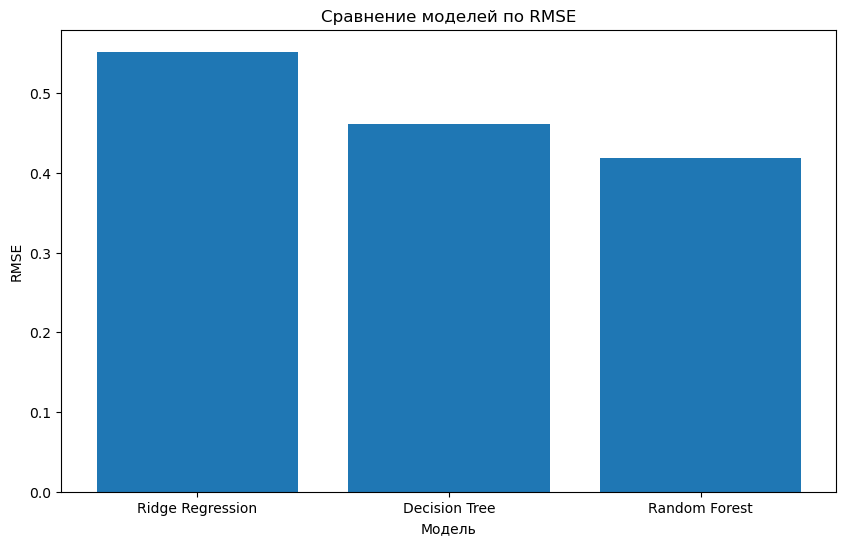

In [96]:
plt.figure(figsize=(10, 6))

plt.bar(
    results['Model'],
    results['RMSE']
)

plt.title('Сравнение моделей по RMSE')
plt.xlabel('Модель')
plt.ylabel('RMSE')

plt.xticks(rotation=0)

plt.show()

# 3.5 Выбор финальной модели

Определим модель с наименьшим значением RMSE и используем её для дальнейшего анализа.

In [97]:
best_model_name = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

print('Финальная модель:', best_model_name)

Финальная модель: Random Forest


In [98]:
if best_model_name == 'Ridge Regression':
    best_model = ridge_best
    best_pred = ridge_best_pred

elif best_model_name == 'Decision Tree':
    best_model = tree_best
    best_pred = tree_best_pred

else:
    best_model = forest_best
    best_pred = forest_best_pred

# 3.6 Фактическая и предсказанная стоимость

Сравним фактические значения стоимости недвижимости с прогнозами выбранной модели.

Чем ближе точки расположены к прямой зависимости, тем ближе прогнозы к фактическим значениям.

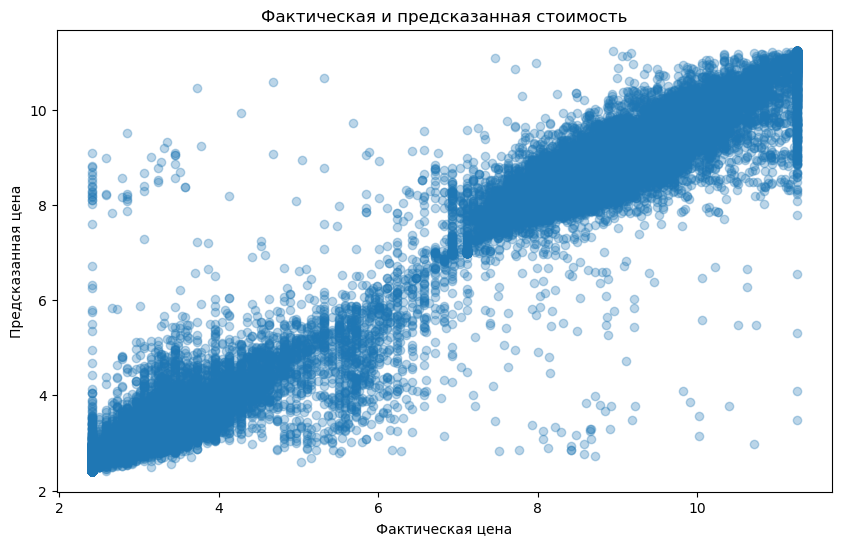

In [99]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.3
)

plt.xlabel('Фактическая цена')
plt.ylabel('Предсказанная цена')
plt.title('Фактическая и предсказанная стоимость')

plt.show()

# 3.7 Анализ остатков

Рассмотрим остатки модели — разницу между фактической и предсказанной стоимостью объектов.

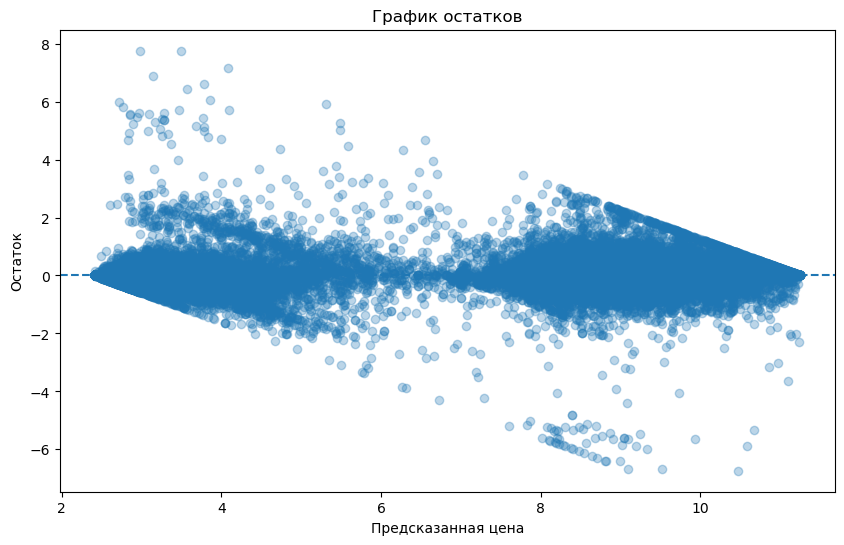

In [100]:
residuals = y_test - best_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    best_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Предсказанная цена')
plt.ylabel('Остаток')
plt.title('График остатков')

plt.show()

#### Сохранение лучшей модели

In [101]:
import joblib

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

['feature_cols.pkl']

Модель, скалер и список признаков успешно сохранены

# Вывод

На третьем этапе были построены три модели регрессии: Ridge Regression, Decision Tree и Random Forest.
Для каждой модели сначала была обучена базовая версия, после чего выполнен подбор гиперпараметров с использованием кросс-валидации. Качество моделей оценивалось по MAE, RMSE, MAPE и R².
После сравнения результатов была выбрана модель, которая показала наиболее подходящие значения метрик. Она будет использоваться на следующем этапе при разработке приложения для прогнозирования стоимости недвижимости.

# Проверка модели на тестовых данных

В соответствии с заданием проверим выбранную модель на 20 объектах из test_real_estate_samples Сначала сформируем признаки в том же формате, что использовался при обучении модели, затем получим прогнозы, рассчитаем MAE, RMSE и R² вручную и с помощью sklearn, сравним результаты и сохраним итоговый файл result_real_estate_samples


## 4.1 Описание используемой модели

В основной работе были построены Ridge Regression, Decision Tree и Random Forest. Для проверки тестовых объектов используется финальная модель, выбранная по минимальному RMSE. Целевая переменная модели — price_log, то есть логарифм цены в долларах. Перед выводом результата прогноз переводится обратно в денежную шкалу.


In [102]:

if 'best_model' in globals():
    assignment_model = best_model
    assignment_model_name = best_model_name
elif 'forest_best' in globals():
    assignment_model = forest_best
    assignment_model_name = 'Random Forest'
else:
    assignment_model = forest_model
    assignment_model_name = 'Random Forest'

print('Модель для проверки:', assignment_model_name)


Модель для проверки: Random Forest


### Подготовка признаков тестовых объектов

Тестовые объекты проходят те же основные преобразования, что и данные для обучения: преобразование дат, возраста здания, этажей, комнат, адреса, категориальных признаков и логарифмирование площади. Для пропущенных числовых значений используются медианы, рассчитанные по данным основной выборки. Для района используется уже рассчитанное в основной работе кодирование district_enc


In [126]:
test_raw = pd.read_csv('test_real_estate_samples.csv', low_memory=False)
test_work = test_raw.copy()

In [128]:
test_translations = {
    'sub_type': {
        'Daire': 'Flat',
        'Villa': 'Villa',
        'Müstakil Ev': 'Detached House',
        'Rezidans': 'Residence',
        'Yazlık': 'Summer House',
        'Komple Bina': 'Entire Building',
        'Prefabrik Ev': 'Prefabricated House',
        'Çiftlik Evi': 'Farm House',
        'Köşk / Konak / Yalı': 'Mansion / Manor / Waterfront Mansion',
        'Yalı Dairesi': 'Waterfront Apartment',
        'Kooperatif': 'Cooperative',
        'Loft': 'Loft'
    },

    'listing_type': {
        1: 'For Sale',
        2: 'For Rent',
        3: 'For Transfer'
    },

    'heating_type': {
        'Kalorifer (Doğalgaz)': 'Central Heating / Natural Gas',
        'Kalorifer (Kömür)': 'Central Heating / Coal',
        'Kombi (Elektrikli)': 'Electric Combi Boiler',
        'Klima': 'Air Conditioning',
        'Kombi (Doğalgaz)': 'Gas Combi Boiler',
        'Merkezi Sistem': 'Central Heating',
        'Merkezi Sistem (Isı Payı Ölçer)': 'Central Heating / Heat Meter',
        'Yerden Isıtma': 'Underfloor Heating',
        'Soba (Kömür)': 'Heating Stove / Coal',
        'Soba (Doğalgaz)': 'Heating Stove / Natural Gas',
        'Güneş Enerjisi': 'Solar Energy',
        'Jeotermal': 'Geothermal Energy',
        'Fancoil': 'Fan Coil',
        'Kat Kaloriferi': 'Individual Central Heating',
        'Kalorifer (Akaryakıt)': 'Central Heating / Fuel Oil',
        'Yok': 'None'
    },

    'building_age': {
        'Sıfır Bina': 'New Building',
        '1 Yaşında': '1 Year',
        '2 Yaşında': '2 Years',
        '3 Yaşında': '3 Years',
        '4 Yaşında': '4 Years',
        '5 Yaşında': '5 Years',
        '6-10 arası': 'Between 6 and 10 years',
        '11-15 arası': 'Between 11 and 15 years',
        '16-20 arası': 'Between 16 and 20 years',
        '21-25 arası': 'Between 21 and 25 years',
        '26-30 arası': 'Between 26 and 30 years',
        '31-35 arası': 'Between 31 and 35 years',
        '36-40 arası': 'Between 36 and 40 years',
        '40 ve üzeri': '40 years or more'
    },

    'floor_no': {
        'Yüksek Giriş': 'High Entrance',
        'Giriş Katı': 'Ground Floor',
        'Giriş kat': 'Ground Floor',
        'Zemin Kat': 'Ground Floor',
        'Kot 1': 'Basement Level 1',
        'Kot 2': 'Basement Level 2',
        'Kot 3': 'Basement Level 3',
        'Kot 4': 'Basement Level 4',
        'Çatı Katı': 'Attic',
        'Bahçe katı': 'Garden Floor',
        'Müstakil': 'Detached',
        'Komple': 'Entire Building',
        '20 ve üzeri': '20 or More',
        'En Üst Kat': 'Top Floor',
        'Bodrum Kat': 'Basement Floor',
        'Teras Kat': 'Terrace Floor',
        'Asma Kat': 'Mezzanine Floor'
    },

    'total_floor_count': {
        '10-20 arası': 'Between 10 and 20 floors',
        '20 ve üzeri': '20 floors or more'
    },

    'furnished': {
        'Eşyalı': 'Furnished',
        'Eşyasız': 'Unfurnished'
    }
}

### Даты и производные признаки

In [123]:

test_work['start_date'] = pd.to_datetime(test_work['start_date'], errors='coerce')
test_work['end_date'] = pd.to_datetime(test_work['end_date'], errors='coerce')
test_work['is_active'] = test_work['end_date'].isna().astype(int)
test_work['duration_days'] = (test_work['end_date'] - test_work['start_date']).dt.days.fillna(0)
test_work['end_month'] = test_work['end_date'].dt.month.fillna(-1).astype(int)


### Возраст здания

In [106]:
age_mapping_test = {
    '6-10 arası': 8,
    '11-15 arası': 13,
    '16-20 arası': 18,
    '21-25 arası': 23,
    '26-30 arası': 28,
    '31-35 arası': 33,
    '36-40 arası': 38,
    '40 ve üzeri': 45,
    'Between 6 and 10 years': 8,
    'Between 11 and 15 years': 13,
    'Between 16 and 20 years': 18,
    'Between 21 and 25 years': 23,
    'Between 26 and 30 years': 28,
    'Between 31 and 35 years': 33,
    'Between 36 and 40 years': 38,
    '40 years or more': 45
}
test_work['building_age'] = pd.to_numeric(
    test_work['building_age'].replace(age_mapping_test),
    errors='coerce'
)
test_work['building_age'] = test_work['building_age'].fillna(
    df['building_age'].median()
)


### Общее количество этажей

In [107]:

floor_count_mapping_test = {
    '10-20 arası': 15,
    '20 ve üzerи': 25,
    '20 ve üzerи': 25,
    'Between 10 and 20 floors': 15,
    '20 floors or more': 25
}
test_work['total_floor_count'] = pd.to_numeric(
    test_work['total_floor_count'].replace(floor_count_mapping_test),
    errors='coerce'
)
test_work['total_floor_count'] = test_work['total_floor_count'].fillna(
    df['total_floor_count'].median()
)


### Этаж объекта

In [108]:
floor_mapping_test = {
    'Yüksek Giriş': 0,
    'Giriş Katı': 0,
    'Giriş kat': 0,
    'Zemin Kat': 0,
    'Kot 1': -1,
    'Kot 2': -2,
    'Kot 3': -3,
    'Kot 4': -4,
    'Çatı Katı': 0,
    'Bahçe katı': -1,
    'Müstakil': 0,
    'Komple': 0,
    '20 ve üzeri': 20,
    'En Üst Kat': 0,
    'Bodrum Kat': -1,
    'Teras Kat': 0,
    'Asma Kat': 0,
    'Ground Floor': 0,
    'High Ground Floor': 0,
    'Garden Floor': -1,
    'Basement Floor': -1,
    'Basement Level 1': -1,
    'Basement Level 2': -2,
    'Basement Level 3': -3,
    'Basement Level 4': -4,
    'Mezzanine Floor': 0.5,
    'Detached': 0,
    'Entire Building': 0,
    '20 or More': 20
}
test_work['floor_no'] = pd.to_numeric(
    test_work['floor_no'].replace(floor_mapping_test),
    errors='coerce'
)
test_work['floor_no'] = test_work['floor_no'].fillna(
    df['floor_no'].median()
)


### Комнаты: формат 2+1 -> 3

In [109]:
def parse_rooms_test(value):
    if pd.isna(value):
        return np.nan
    parts = str(value).replace(' ', '').split('+')
    try:
        return sum(int(p) for p in parts if p.isdigit())
    except ValueError:
        return np.nan

test_work['room_count_num'] = test_work['room_count'].apply(parse_rooms_test)
test_work['room_count_num'] = test_work['room_count_num'].fillna(
    df['room_count_num'].median()
)


### Площадь и логарифм площади

In [110]:
test_work['size'] = pd.to_numeric(test_work['size'], errors='coerce')
test_work['size'] = test_work['size'].fillna(df['size'].median())
test_work['size'] = test_work['size'].clip(
    df['size'].quantile(0.01),
    df['size'].quantile(0.99)
)
test_work['size_log'] = np.log1p(test_work['size'])


### Адрес -> город и район

In [111]:
address_parts = test_work['address'].astype(str).str.split('/')
test_work['city'] = address_parts.str[0].str.strip()
test_work['district'] = address_parts.str[1].str.strip()


# Кодирование района

In [112]:
test_work['district_enc'] = test_work['district'].map(
    district_mean
).fillna(y.mean())


### One-Hot Encoding

In [113]:
test_work = pd.get_dummies(
    test_work,
    columns=['sub_type', 'listing_type', 'heating_type', 'city'],
    drop_first=False,
    dtype=int
)


### Формируем ровно тот же набор признаков, что использует модель

In [114]:
X_test_samples = test_work.reindex(
    columns=feature_cols,
    fill_value=0
).astype(float)

print('Размер тестовых данных:', X_test_samples.shape)


Размер тестовых данных: (20, 117)


## 4.2 Проверка модели на 20 тестовых объектах

Получаем прогноз для каждого объекта. Модель прогнозирует price_log, поэтому сначала возвращаемся из логарифмической шкалы к цене в USD, а затем переводим прогноз в TRY, чтобы сопоставить его с исходным столбцом price


In [115]:
predicted_price_usd = np.expm1(
    assignment_model.predict(X_test_samples)
)

test_rates = {
    'TRY': 49.01,
    'USD': 1,
    'EUR': 0.88,
    'GBP': 0.75
}

predicted_price_try = (
    predicted_price_usd
    * test_raw['price_currency'].map(test_rates).fillna(49.01).to_numpy()
)

result_table = test_raw.copy()


### По заданию ФИО и группа должны присутствовать в итоговом файле

In [116]:
result_table['ФИО'] = 'Рухтина Полина'
result_table['Группа'] = '23П-2'

### Ошибки нужны для ручного расчёта метрик

In [117]:

result_table['Абсолютная ошибка'] = np.abs(
    result_table['price'].to_numpy() - predicted_price_try
)
result_table['Квадрат ошибки'] = (
    result_table['price'].to_numpy() - predicted_price_try
) ** 2


### Прогноз оставляем последним столбцом

In [118]:

result_table['Прогноз модели, TRY'] = predicted_price_try

result_table = result_table[
    ['ФИО', 'Группа']
    + list(test_raw.columns)
    + ['Абсолютная ошибка', 'Квадрат ошибки', 'Прогноз модели, TRY']
]

result_table


,ФИО,Группа,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,...,room_count,size,address,furnished,heating_type,price,price_currency,Абсолютная ошибка,Квадрат ошибки,"Прогноз модели, TRY"
0,Рухтина Полина,23П-2,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,0,...,1+0,1.0,İzmir/Aliağa/Yenişakran,NaN,Fancoil,300000.0,TRY,1.102012e+04,1.214430e+08,3.110201e+05
1,Рухтина Полина,23П-2,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,2,...,2+2,250.0,İzmir/Foça/Yeniköy,NaN,Yok,1600000.0,TRY,6.077638e+05,3.693769e+11,9.922362e+05
2,Рухтина Полина,23П-2,2,Konut,Daire,2/13/19,NaN,1,14,0,...,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY,1.763839e+05,3.111127e+10,3.136161e+05
3,Рухтина Полина,23П-2,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,NaN,...,3+1,122.0,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Yok,103600.0,TRY,1.443455e+04,2.083564e+08,1.180346e+05
4,Рухтина Полина,23П-2,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,0,...,1+0,1.0,İzmir/Aliağa/Yenişakran,NaN,Fancoil,300000.0,TRY,1.094486e+04,1.197899e+08,3.109449e+05
5,Рухтина Полина,23П-2,100,Konut,Yazlık,1/12/19,NaN,1,46,1,...,3+1,150.0,Mersin/Erdemli/Kargıpınarı,NaN,Fancoil,500000.0,TRY,7.438753e+04,5.533504e+09,4.256125e+05
6,Рухтина Полина,23П-2,320,Konut,Yazlık,2/12/19,2/12/19,1,0,0,...,4+1,134.0,Balıkesir/Burhaniye/Pelitköy,NaN,Fancoil,1000000.0,TRY,5.361790e+05,2.874879e+11,4.638210e+05
7,Рухтина Полина,23П-2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,...,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY,2.648244e+04,7.013196e+08,1.814824e+05
8,Рухтина Полина,23П-2,7810,Konut,Loft,12/30/18,1/29/19,1,30,NaN,...,4+1,145.0,İzmir/Konak/Akın Simav,NaN,Kalorifer (Doğalgaz),650000.0,TRY,7.856275e+04,6.172105e+09,5.714373e+05
9,Рухтина Полина,23П-2,11,Konut,Müstakil Ev,11/13/18,11/26/18,1,13,0,...,3+1,125.0,Muğla/Bodrum/Ortakentyahşi,NaN,Fancoil,2450000.0,TRY,5.624324e+05,3.163302e+11,1.887568e+06


## 4.3 Расчёт MAE, RMSE и R2 вручную

Ручной расчёт выполняется по формулам:

- MAE = среднее абсолютное отклонение фактической цены от прогноза;
- RMSE = квадратный корень из среднего квадрата ошибки;
- R2 = 1 − сумма квадратов ошибок / сумма квадратов отклонений фактических значений от их среднего.


In [119]:
y_true_samples = result_table['price'].to_numpy(dtype=float)
y_pred_samples = result_table['Прогноз модели, TRY'].to_numpy(dtype=float)

mae_manual = np.mean(
    np.abs(y_true_samples - y_pred_samples)
)

rmse_manual = np.sqrt(
    np.mean((y_true_samples - y_pred_samples) ** 2)
)

r2_manual = 1 - (
    np.sum((y_true_samples - y_pred_samples) ** 2)
    / np.sum((y_true_samples - np.mean(y_true_samples)) ** 2)
)

manual_metrics = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'R²'],
    'Вручную': [mae_manual, rmse_manual, r2_manual]
})

manual_metrics


,Метрика,Вручную
0,MAE,495826.565761
1,RMSE,712600.605261
2,R²,-0.303722


## 4.4 Расчёт метрик с помощью методов sklearn


In [120]:
mae_sklearn = mean_absolute_error(
    y_true_samples,
    y_pred_samples
)

rmse_sklearn = np.sqrt(
    mean_squared_error(y_true_samples, y_pred_samples)
)

r2_sklearn = r2_score(
    y_true_samples,
    y_pred_samples
)

metrics_comparison = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'R²'],
    'Вручную': [mae_manual, rmse_manual, r2_manual],
    'sklearn': [mae_sklearn, rmse_sklearn, r2_sklearn]
})

metrics_comparison['Разница'] = (
    metrics_comparison['Вручную']
    - metrics_comparison['sklearn']
)

metrics_comparison


,Метрика,Вручную,sklearn,Разница
0,MAE,495826.565761,495826.565761,0.0
1,RMSE,712600.605261,712600.605261,0.0
2,R²,-0.303722,-0.303722,0.0


## 4.5 Анализ полученных результатов

Полученные прогнозы сравниваются с фактическими ценами 20 тестовых объектов. MAE показывает среднюю абсолютную ошибку прогноза в TRY, RMSE сильнее учитывает крупные ошибки, а R2 показывает долю вариации фактических цен, объяснённую моделью на этой небольшой тестовой выборке.

Ручной расчёт и расчёт средствами sklearn должны совпадать с учётом погрешности округления. Результаты на 20 объектах следует рассматривать как дополнительную проверку модели, а не как замену основной оценки на всей тестовой выборке.


In [121]:
print('Результаты отдельной работы')
print('Модель:', assignment_model_name)
print(f'MAE  : {mae_sklearn:,.2f} TRY')
print(f'RMSE : {rmse_sklearn:,.2f} TRY')
print(f'R²   : {r2_sklearn:.4f}')

result_table.to_csv(
    'result_real_estate_samples.csv',
    index=False,
    encoding='utf-8-sig'
)

print('\nФайл result_real_estate_samples.csv сохранён.')


Результаты отдельной работы
Модель: Random Forest
MAE  : 495,826.57 TRY
RMSE : 712,600.61 TRY
R²   : -0.3037

Файл result_real_estate_samples.csv сохранён.


### Итог

Модель была проверена на 20 новых объектах из test_real_estate_samples Для каждого объекта получен прогноз стоимости, после чего MAE, RMSE и R2 были рассчитаны двумя способами — вручную по формулам и с использованием sklearn. Итоговая таблица содержит ФИО, группу, исходные данные объекта, ошибки расчёта и прогноз модели последним столбцом
